In [5]:
import pandas as pd

fake = pd.read_csv("../data/archive/fake.csv")
true = pd.read_csv("../data/archive/true.csv")

In [6]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [7]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [8]:
true.shape


(21417, 4)

In [9]:
true.columns

Index(['title', 'text', 'subject', 'date'], dtype='object')

In [10]:
true["text"].head(3)

0    WASHINGTON (Reuters) - The head of a conservat...
1    WASHINGTON (Reuters) - Transgender people will...
2    WASHINGTON (Reuters) - The special counsel inv...
Name: text, dtype: object

In [11]:
print(true.loc[3,"text"])

WASHINGTON (Reuters) - Trump campaign adviser George Papadopoulos told an Australian diplomat in May 2016 that Russia had political dirt on Democratic presidential candidate Hillary Clinton, the New York Times reported on Saturday. The conversation between Papadopoulos and the diplomat, Alexander Downer, in London was a driving factor behind the FBI’s decision to open a counter-intelligence investigation of Moscow’s contacts with the Trump campaign, the Times reported. Two months after the meeting, Australian officials passed the information that came from Papadopoulos to their American counterparts when leaked Democratic emails began appearing online, according to the newspaper, which cited four current and former U.S. and foreign officials. Besides the information from the Australians, the probe by the Federal Bureau of Investigation was also propelled by intelligence from other friendly governments, including the British and Dutch, the Times said. Papadopoulos, a Chicago-based inter

In [12]:
fake.columns

Index(['title', 'text', 'subject', 'date'], dtype='object')

In [13]:
fake.shape

(23481, 4)

In [14]:
fake['label'] = 'fake'
true['label'] = 'true'

df = pd.concat([fake,true],ignore_index=True)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df['label'].value_counts())

label
fake    23481
true    21417
Name: count, dtype: int64


In [15]:
df.to_csv("../data/archive/combined_dataset.csv")

In [16]:
fake.shape

(23481, 5)

In [17]:
fake.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [18]:
from sklearn.model_selection import train_test_split

train_df,test_df = train_test_split(
    df,
    test_size=0.5,
    stratify=df['label'],
    random_state=42
)

In [19]:
train_df.to_csv("../data/train/train_data.csv")
test_df.to_csv("../data/test/test_data.csv")

In [20]:
print(train_df['label'].value_counts())

label
fake    11740
true    10709
Name: count, dtype: int64


In [21]:
print(test_df['label'].value_counts())

label
fake    11741
true    10708
Name: count, dtype: int64


In [22]:



df['word_count'] = df['text'].astype(str).apply(lambda x : len(x.split()))

df.groupby('label')['word_count'].agg([
    'count',
    'mean',
    'median',
    'min',
    'max'
    ])


fake_words = df[df['label'] == 'fake']['word_count']
true_words = df[df['label'] == 'true']['word_count']

fake_words.count(), fake_words.mean(), fake_words.median()
true_words.count(), true_words.mean(), true_words.median()


(21417, 385.6400989867862, 359.0)

Text(0.5, 0.98, '')

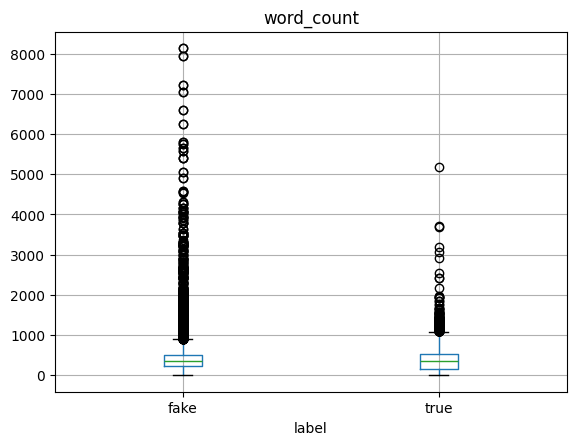

In [26]:
import matplotlib.pyplot as plt

df.boxplot(column='word_count',by='label')
plt.suptitle("")


In [27]:
test_no_label = test_df.drop(columns='label')
test_no_label.to_csv("../data/test/test_no_label.csv")
print("saved ;)")

saved ;)
